In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [95]:
from xgboost import XGBRegressor

In [96]:
df = pd.read_csv("../data/processed/smartstock_features.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Shape:", df.shape)
df.head()

Shape: (70100, 25)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Day_of_Week,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,day_of_week,month,week_of_year
0,2022-01-31,S001,P0001,Clothing,West,410,200,152,212.24,70.78,...,Monday,130.0,9.0,69.0,127.0,97.857143,114.233333,0,1,5
1,2022-02-01,S001,P0001,Groceries,East,419,279,84,297.26,34.49,...,Tuesday,200.0,189.0,123.0,81.0,125.142857,116.666667,1,2,5
2,2022-02-02,S001,P0001,Electronics,South,415,38,149,53.13,52.49,...,Wednesday,279.0,49.0,211.0,5.0,138.000000,123.266667,2,2,5
3,2022-02-03,S001,P0001,Clothing,South,345,71,186,84.02,27.71,...,Thursday,38.0,164.0,79.0,58.0,136.428571,124.366667,3,2,5
4,2022-02-04,S001,P0001,Furniture,South,121,25,25,37.72,16.84,...,Friday,71.0,97.0,390.0,147.0,123.142857,124.800000,4,2,5


In [97]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "day_of_week",
    "month",
    "week_of_year"
]

target = "Units Sold"

In [98]:
split_date = df["Date"].quantile(0.80)

train = df[df["Date"] < split_date].copy()
test = df[df["Date"] >= split_date].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (56000, 9)
Testing: (14100, 9)


In [99]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [100]:
rf_pred = rf_model.predict(X_test)

print("First 10 predictions:")
print(rf_pred[:10])

First 10 predictions:
[167.45 112.76 158.8  164.67 143.5  133.85 125.26 154.1  154.97 138.91]


In [101]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 90.77593475177305
Random Forest RMSE: 109.8164693521174


In [102]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [103]:
xgb_pred = xgb_model.predict(X_test)

print("First 10 XGBoost predictions:")
print(xgb_pred[:10])

First 10 XGBoost predictions:
[148.07697 142.13286 119.69165 138.97382 137.01782 134.76268 132.05148
 143.22346 148.07214 128.97758]


In [104]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 89.09751892089844
XGBoost RMSE: 108.72872008035641


In [105]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance

rolling_mean_30    0.118146
week_of_year       0.116414
rolling_mean_7     0.115934
lag_30             0.113992
lag_14             0.111937
lag_7              0.109923
lag_1              0.108696
day_of_week        0.105072
month              0.099885
dtype: float32

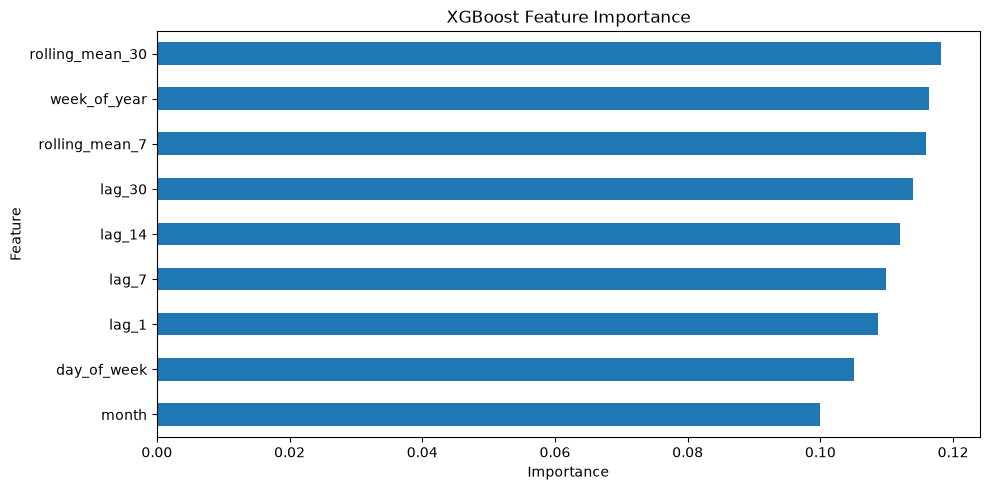

In [106]:
plt.figure(figsize=(10, 5))

feature_importance.sort_values().plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [107]:
comparison = pd.DataFrame({
    "Date": test["Date"].values,
    "Actual": y_test.values,
    "Predicted": xgb_pred
})

comparison.head()

,Date,Actual,Predicted
0,2023-08-14,72,148.076965
1,2023-08-15,289,142.132858
2,2023-08-16,50,119.691650
3,2023-08-17,225,138.973816
4,2023-08-18,293,137.017822


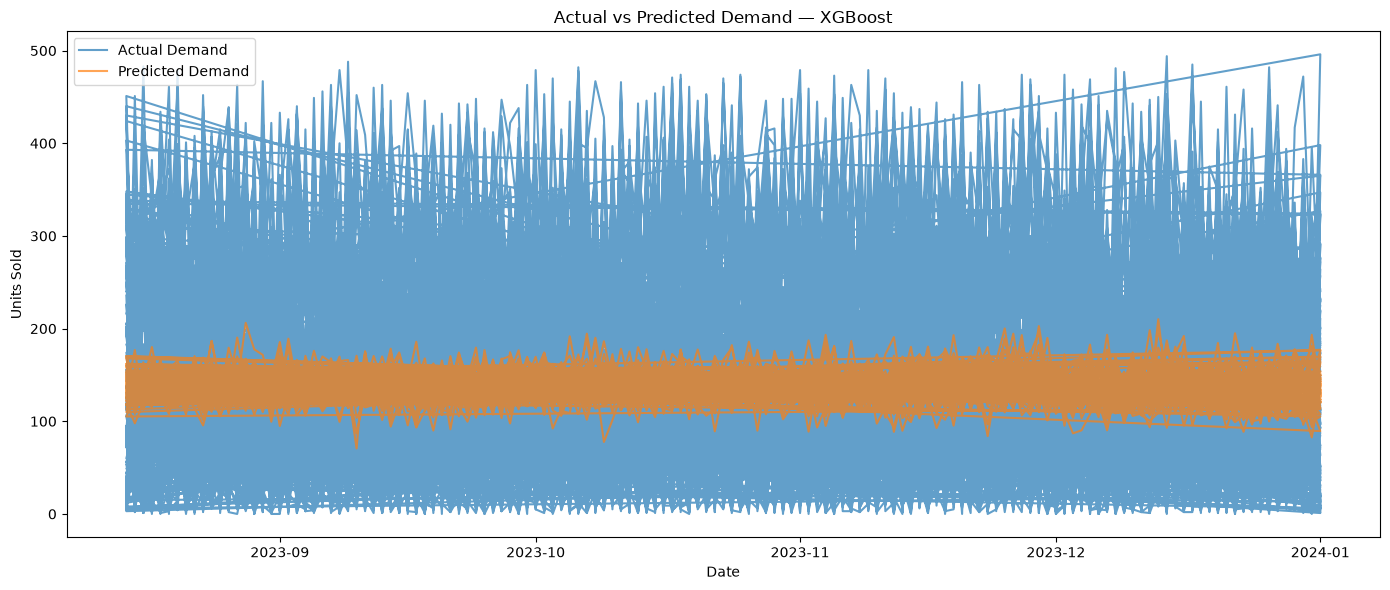

In [108]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual Demand",
    alpha=0.7
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted Demand",
    alpha=0.7
)

plt.title("Actual vs Predicted Demand — XGBoost")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.tight_layout()
plt.show()

In [109]:
# Select one store-product combination
sample_store = "S001"
sample_product = "P0001"

sample = comparison[
    (test["Store ID"].values == sample_store) &
    (test["Product ID"].values == sample_product)
].copy()

sample.head()

,Date,Actual,Predicted
0,2023-08-14,72,148.076965
1,2023-08-15,289,142.132858
2,2023-08-16,50,119.691650
3,2023-08-17,225,138.973816
4,2023-08-18,293,137.017822


In [110]:
sample = test[
    (test["Store ID"] == "S001") &
    (test["Product ID"] == "P0001")
].copy()

sample["Predicted"] = xgb_pred[
    test["Store ID"].eq("S001") &
    test["Product ID"].eq("P0001")
]

sample.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,day_of_week,month,week_of_year,Predicted
560,2023-08-14,S001,P0001,Groceries,South,386,72,181,88.02,51.70,...,145.0,14.0,6.0,46.0,180.142857,172.166667,0,8,33,148.076965
561,2023-08-15,S001,P0001,Clothing,West,408,289,148,285.27,46.93,...,72.0,335.0,109.0,202.0,188.428571,173.033333,1,8,33,142.132858
562,2023-08-16,S001,P0001,Clothing,South,64,50,54,47.62,63.26,...,289.0,455.0,154.0,83.0,181.857143,175.933333,2,8,33,119.691650
563,2023-08-17,S001,P0001,Groceries,West,241,225,130,243.91,36.85,...,50.0,176.0,435.0,183.0,124.000000,174.833333,3,8,33,138.973816
564,2023-08-18,S001,P0001,Clothing,East,333,293,111,306.29,19.63,...,225.0,90.0,55.0,334.0,131.000000,176.233333,4,8,33,137.017822


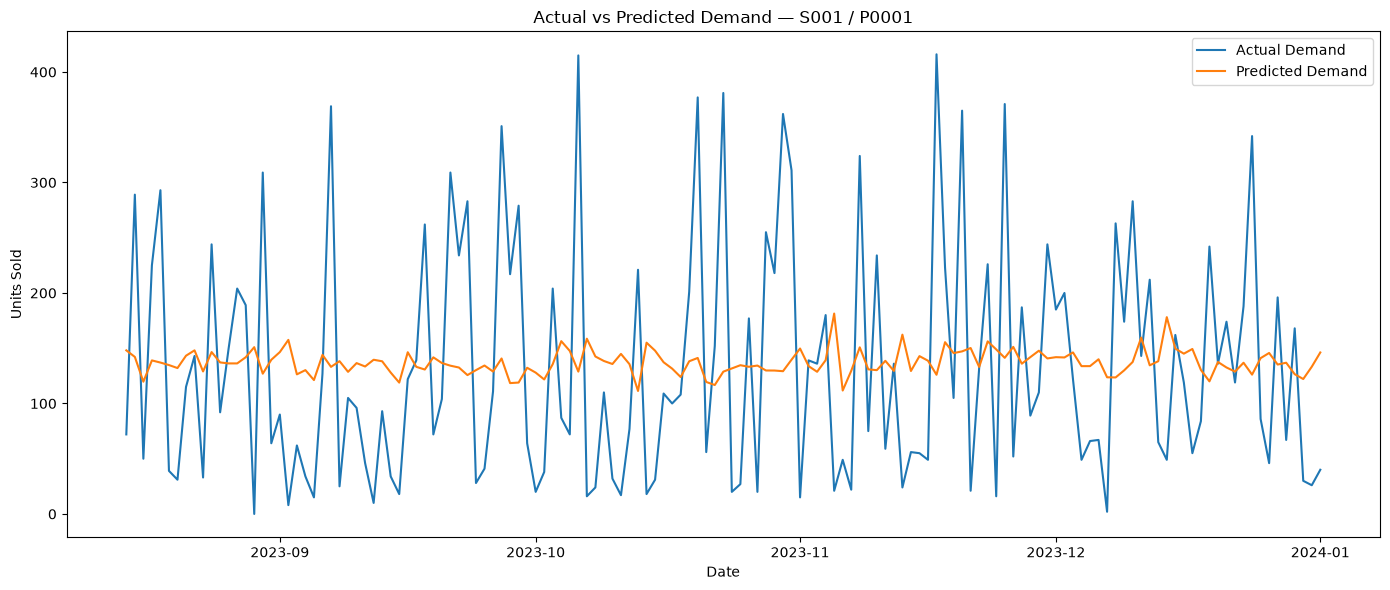

In [111]:
plt.figure(figsize=(14, 6))

plt.plot(
    sample["Date"],
    sample["Units Sold"],
    label="Actual Demand"
)

plt.plot(
    sample["Date"],
    sample["Predicted"],
    label="Predicted Demand"
)

plt.title("Actual vs Predicted Demand — S001 / P0001")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.tight_layout()
plt.show()

In [112]:
baseline_pred = test["rolling_mean_7"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 93.21936170212766
Baseline RMSE: 115.46352486343525


In [113]:
results = pd.DataFrame({
    "Model": [
        "7-Day Rolling Average",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_rmse,
        xgb_rmse
    ]
})

results

,Model,MAE,RMSE
0,7-Day Rolling Average,93.219362,115.463525
1,Random Forest,90.775935,109.816469
2,XGBoost,89.097519,108.728720


In [114]:
test_results = test.copy()

test_results["Predicted Demand"] = xgb_pred

test_results[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Inventory Level",
        "Units Sold",
        "Predicted Demand"
    ]
].head(10)

,Date,Store ID,Product ID,Inventory Level,Units Sold,Predicted Demand
560,2023-08-14,S001,P0001,386,72,148.076965
561,2023-08-15,S001,P0001,408,289,142.132858
562,2023-08-16,S001,P0001,64,50,119.691650
563,2023-08-17,S001,P0001,241,225,138.973816
564,2023-08-18,S001,P0001,333,293,137.017822
565,2023-08-19,S001,P0001,307,39,134.762680
566,2023-08-20,S001,P0001,184,31,132.051483
567,2023-08-21,S001,P0001,121,115,143.223465
568,2023-08-22,S001,P0001,182,143,148.072144
569,2023-08-23,S001,P0001,438,33,128.977585


In [115]:
test_results["Inventory Coverage"] = (
    test_results["Inventory Level"] /
    test_results["Predicted Demand"]
)

In [116]:
test_results[
    [
        "Store ID",
        "Product ID",
        "Inventory Level",
        "Predicted Demand",
        "Inventory Coverage"
    ]
].head(10)

,Store ID,Product ID,Inventory Level,Predicted Demand,Inventory Coverage
560,S001,P0001,386,148.076965,2.606753
561,S001,P0001,408,142.132858,2.870554
562,S001,P0001,64,119.691650,0.534707
563,S001,P0001,241,138.973816,1.734140
564,S001,P0001,333,137.017822,2.430341
565,S001,P0001,307,134.762680,2.278079
566,S001,P0001,184,132.051483,1.393396
567,S001,P0001,121,143.223465,0.844834
568,S001,P0001,182,148.072144,1.229131
569,S001,P0001,438,128.977585,3.395939


In [117]:
test_results["Inventory Coverage"].describe()

count    14100.000000
mean         2.020173
std          0.979535
min          0.287184
25%          1.177921
50%          1.989730
75%          2.829400
max          5.637352
Name: Inventory Coverage, dtype: float64

In [118]:
def classify_inventory_risk(coverage):
    if coverage < 1:
        return "High Risk"
    elif coverage < 2:
        return "Medium Risk"
    elif coverage <= 3:
        return "Low Risk"
    else:
        return "Overstock"

In [119]:
test_results["Inventory Risk"] = (
    test_results["Inventory Coverage"]
    .apply(classify_inventory_risk)
)

In [120]:
test_results["Inventory Risk"].value_counts()

Inventory Risk
Medium Risk    4372
Low Risk       4164
Overstock      2846
High Risk      2718
Name: count, dtype: int64

In [121]:
test_results["Inventory Risk"].value_counts(normalize=True).mul(100).round(2)

Inventory Risk
Medium Risk    31.01
Low Risk       29.53
Overstock      20.18
High Risk      19.28
Name: proportion, dtype: float64

## Walk-Forward Validation

In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

In [123]:
import pandas as pd

df_model = pd.read_csv(
    "../data/processed/smartstock_features.csv"
)

df_model["Date"] = pd.to_datetime(df_model["Date"])

print(df_model.shape)
df_model.head()

(70100, 25)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Day_of_Week,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,day_of_week,month,week_of_year
0,2022-01-31,S001,P0001,Clothing,West,410,200,152,212.24,70.78,...,Monday,130.0,9.0,69.0,127.0,97.857143,114.233333,0,1,5
1,2022-02-01,S001,P0001,Groceries,East,419,279,84,297.26,34.49,...,Tuesday,200.0,189.0,123.0,81.0,125.142857,116.666667,1,2,5
2,2022-02-02,S001,P0001,Electronics,South,415,38,149,53.13,52.49,...,Wednesday,279.0,49.0,211.0,5.0,138.000000,123.266667,2,2,5
3,2022-02-03,S001,P0001,Clothing,South,345,71,186,84.02,27.71,...,Thursday,38.0,164.0,79.0,58.0,136.428571,124.366667,3,2,5
4,2022-02-04,S001,P0001,Furniture,South,121,25,25,37.72,16.84,...,Friday,71.0,97.0,390.0,147.0,123.142857,124.800000,4,2,5


In [124]:
# Sort the data chronologically
df_model = df_model.sort_values("Date").reset_index(drop=True)

features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "day_of_week",
    "month",
    "week_of_year"
]

target = "Units Sold"

In [125]:
unique_dates = sorted(df_model["Date"].unique())

n_dates = len(unique_dates)

train_end_points = [
    int(n_dates * 0.60),
    int(n_dates * 0.70),
    int(n_dates * 0.80)
]

test_size = int(n_dates * 0.10)

walk_forward_results = []
walk_forward_errors = []

for i, train_end in enumerate(train_end_points, start=1):

    train_dates = unique_dates[:train_end]

    test_start = train_end
    test_end = min(train_end + test_size, n_dates)

    test_dates = unique_dates[test_start:test_end]

    train_data = df_model[
        df_model["Date"].isin(train_dates)
    ]

    test_data = df_model[
        df_model["Date"].isin(test_dates)
    ]

    X_train = train_data[features]
    y_train = train_data[target]

    X_test = test_data[features]
    y_test = test_data[target]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    
    errors = y_test.values - predictions

    walk_forward_errors.extend(errors)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    walk_forward_results.append({
        "Fold": i,
        "Train Start": train_dates[0],
        "Train End": train_dates[-1],
        "Test Start": test_dates[0],
        "Test End": test_dates[-1],
        "MAE": mae,
        "RMSE": rmse
    })

In [126]:
walk_forward_results = pd.DataFrame(
    walk_forward_results
)

walk_forward_results

,Fold,Train Start,Train End,Test Start,Test End,MAE,RMSE
0,1,2022-01-31,2023-03-26,2023-03-27,2023-06-04,89.931664,110.627737
1,2,2022-01-31,2023-06-04,2023-06-05,2023-08-13,90.908699,111.004782
2,3,2022-01-31,2023-08-13,2023-08-14,2023-10-22,89.166481,108.937321


In [127]:
avg_mae = walk_forward_results["MAE"].mean()
avg_rmse = walk_forward_results["RMSE"].mean()

print(f"Average MAE: {avg_mae:.2f}")
print(f"Average RMSE: {avg_rmse:.2f}")

Average MAE: 90.00
Average RMSE: 110.19


In [128]:
walk_forward_results.to_csv(
    "../data/processed/walk_forward_results.csv",
    index=False
)

## Inventory Reorder Optimization

The reorder recommendation incorporates supplier lead time and
forecast uncertainty.

Assumptions:
- Lead time = 7 days
- Target service level = 95%
- Daily demand forecasts are used to estimate lead-time demand

In [129]:
lead_time_days = 7
service_level_z = 1.645

In [130]:
test_results = pd.read_csv(
    "../data/processed/test_predictions.csv"
)

test_results["Date"] = pd.to_datetime(
    test_results["Date"]
)

In [131]:
test_results["Forecast Error"] = (
    test_results["Units Sold"] -
    test_results["Predicted Demand"]
)

In [132]:
error_std_by_product = (
    test_results
    .groupby(["Store ID", "Product ID"])["Forecast Error"]
    .std()
    .reset_index(name="Error Std")
)

error_std_by_product.head()

,Store ID,Product ID,Error Std
0,S001,P0001,109.666458
1,S001,P0002,99.483740
2,S001,P0003,112.464874
3,S001,P0004,114.303075
4,S001,P0005,108.517499


In [133]:
test_results = test_results.drop(
    columns=["Error Std"],
    errors="ignore"
)

test_results = test_results.merge(
    error_std_by_product,
    on=["Store ID", "Product ID"],
    how="left"
)

In [134]:
test_results["Safety Stock"] = (
    service_level_z *
    test_results["Error Std"] *
    np.sqrt(lead_time_days)
)

test_results["Safety Stock"] = np.ceil(
    test_results["Safety Stock"]
).astype(int)

In [135]:
test_results["Lead Time Demand"] = (
    test_results["Predicted Demand"] *
    lead_time_days
)

test_results["Reorder Point"] = (
    test_results["Lead Time Demand"] +
    test_results["Safety Stock"]
)

test_results["Reorder Point"] = np.ceil(
    test_results["Reorder Point"]
).astype(int)

In [136]:
test_results["Recommended Reorder"] = (
    test_results["Reorder Point"] -
    test_results["Inventory Level"]
).clip(lower=0)

test_results["Recommended Reorder"] = np.ceil(
    test_results["Recommended Reorder"]
).astype(int)

In [137]:
test_results["Safety Stock"].describe()

count    14100.000000
mean       472.800000
std         30.143398
min        401.000000
25%        451.000000
50%        476.000000
75%        494.000000
max        540.000000
Name: Safety Stock, dtype: float64

## Final Inventory Outputs

In [138]:
test_results[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Units Sold",
        "Predicted Demand",
        "Inventory Level",
        "Inventory Risk",
        "Error Std",
        "Safety Stock",
        "Lead Time Demand",
        "Reorder Point",
        "Recommended Reorder"
    ]
].head(10)

,Date,Store ID,Product ID,Units Sold,Predicted Demand,Inventory Level,Inventory Risk,Error Std,Safety Stock,Lead Time Demand,Reorder Point,Recommended Reorder
0,2023-08-14,S001,P0001,72,148.07697,386,Low Risk,109.666458,478,1036.53879,1515,1129
1,2023-08-15,S001,P0001,289,142.13286,408,Low Risk,109.666458,478,994.93002,1473,1065
2,2023-08-16,S001,P0001,50,119.69165,64,High Risk,109.666458,478,837.84155,1316,1252
3,2023-08-17,S001,P0001,225,138.97382,241,Medium Risk,109.666458,478,972.81674,1451,1210
4,2023-08-18,S001,P0001,293,137.01782,333,Low Risk,109.666458,478,959.12474,1438,1105
5,2023-08-19,S001,P0001,39,134.76268,307,Low Risk,109.666458,478,943.33876,1422,1115
6,2023-08-20,S001,P0001,31,132.05148,184,Medium Risk,109.666458,478,924.36036,1403,1219
7,2023-08-21,S001,P0001,115,143.22346,121,High Risk,109.666458,478,1002.56422,1481,1360
8,2023-08-22,S001,P0001,143,148.07214,182,Medium Risk,109.666458,478,1036.50498,1515,1333
9,2023-08-23,S001,P0001,33,128.97758,438,Overstock,109.666458,478,902.84306,1381,943


In [139]:
inventory_summary = (
    test_results
    .groupby(["Store ID", "Product ID"])
    .agg(
        Avg_Inventory=("Inventory Level", "mean"),
        Avg_Predicted_Demand=("Predicted Demand", "mean"),
        Avg_Safety_Stock=("Safety Stock", "mean"),
        Avg_Reorder_Point=("Reorder Point", "mean"),
        Total_Reorder=("Recommended Reorder", "sum"),
        High_Risk_Days=(
            "Inventory Risk",
            lambda x: (x == "High Risk").sum()
        ),
        Overstock_Days=(
            "Inventory Risk",
            lambda x: (x == "Overstock").sum()
        )
    )
    .reset_index()
)

inventory_summary.head()

,Store ID,Product ID,Avg_Inventory,Avg_Predicted_Demand,Avg_Safety_Stock,Avg_Reorder_Point,Total_Reorder,High_Risk_Days,Overstock_Days
0,S001,P0001,263.148936,137.130833,478.0,1438.432624,165715,31,28
1,S001,P0002,275.645390,136.045526,433.0,1385.836879,156537,25,31
2,S001,P0003,279.780142,137.341118,490.0,1451.907801,165270,27,28
3,S001,P0004,274.241135,141.298526,498.0,1487.553191,171077,30,28
4,S001,P0005,263.716312,136.536309,473.0,1429.262411,164342,29,26


In [140]:
test_results.to_csv(
    "../data/processed/test_predictions.csv",
    index=False
)

inventory_summary.to_csv(
    "../data/processed/inventory_summary.csv",
    index=False
)

walk_forward_results.to_csv(
    "../data/processed/walk_forward_results.csv",
    index=False
)

print("Final SmartStock outputs saved successfully.")

Final SmartStock outputs saved successfully.


## Model Explainability

Feature importance is used to understand which demand-history and
calendar features contribute most to the XGBoost forecasting model.

In [141]:
feature_importance = (
    pd.Series(
        xgb_model.feature_importances_,
        index=features
    )
    .sort_values(ascending=False)
)

feature_importance_df = (
    feature_importance
    .reset_index()
)

feature_importance_df.columns = [
    "Feature",
    "Importance"
]

feature_importance_df

,Feature,Importance
0,rolling_mean_30,0.118146
1,week_of_year,0.116414
2,rolling_mean_7,0.115934
3,lag_30,0.113992
4,lag_14,0.111937
5,lag_7,0.109923
6,lag_1,0.108696
7,day_of_week,0.105072
8,month,0.099885


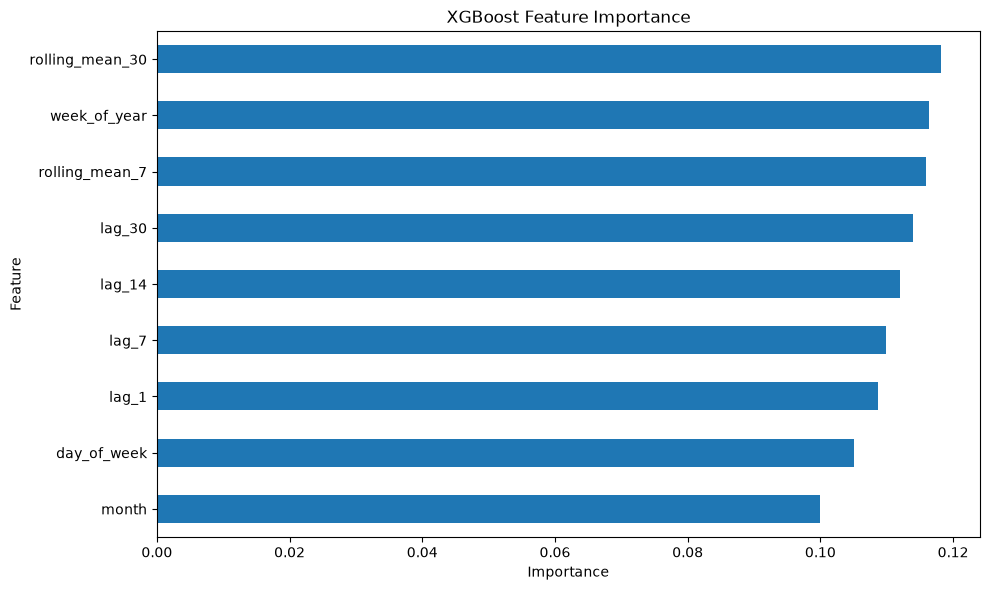

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(
    kind="barh"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Interpretation

The feature importance results show which historical demand and
calendar features contribute most strongly to the XGBoost model's
predictions.

Lag and rolling-demand features capture recent sales patterns,
while calendar features capture recurring temporal effects.

Feature importance indicates the model's reliance on a feature,
but it does not explain the direction of the feature's effect on
an individual prediction.

In [143]:
feature_importance_df.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.
